<a href="https://colab.research.google.com/github/shreyasat27/MSc-QT-/blob/main/paper1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install qutip

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28.5/28.5 MB 34.1 MB/s eta 0:00:00


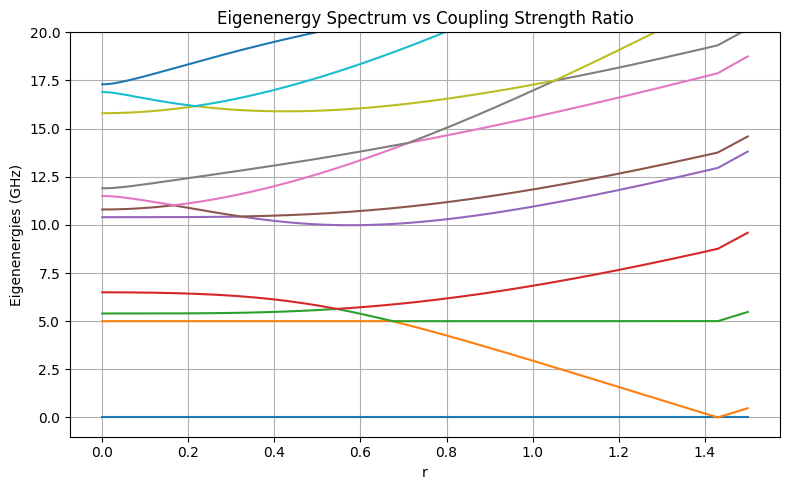

[-2.5  2.5  2.9  4.   7.9  8.3  9.   9.4 13.3 14.4 14.8 19.8]


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import *

# ----- Parameters -----
omega_R = 5.4 * 2 * np.pi    # GHz -> rad/s
E_plus = 18 * 2 * np.pi     # GHz
E_minus = 8 * 2 * np.pi   # GHz
tunnel_coupling = 9.6 * 2 * np.pi

phi = np.pi / 4               # 45 degrees for tunneling
theta = np.pi / 4             # 45 degrees for g_a/g_b

t_sc = tunnel_coupling * np.cos(phi)
t_sf = tunnel_coupling * np.sin(phi)

# Coupling scan
g0_vals = np.linspace(0, 1.5 * omega_R, 1000)   # GHz range converted to rad/s
g_angle = np.pi / 4                            # 45 degrees

# ----- System dimensions -----
Nph = 3             # photon cutoff
Ndot = 4            # 4-level system (|L↑>, |L↓>, |R↑>, |R↓>)

# Operators on dot+spin system
I4 = qeye(Ndot)
a = destroy(Nph)
adag = a.dag()
Iph = qeye(Nph)

# Define the system states in this order:
# |L↑>, |L↓>, |R↑>, |R↓>
# Define Pauli-like ops for spin (σ) and dot (τ)
# Custom matrices for 4-level space (manually construct):

# σ_z acts on spin up/down
sigma_z = Qobj(np.diag([1, -1, 1, -1]))
sigma_p = Qobj([[0, 1, 0, 0],
                [0, 0, 0, 0],
                [0, 0, 0, 1],
                [0, 0, 0, 0]])
sigma_m = sigma_p.dag()

# τ_z acts on L/R
tau_z = Qobj([[1, 0, -1, 0],
              [0, 1, 0, -1],
              [-1, 0, 1, 0],
              [0, -1, 0, 1]]) / 2

tau_p = Qobj([[0, 0, 1, 0],
              [0, 0, 0, 1],
              [0, 0, 0, 0],
              [0, 0, 0, 0]])
tau_m = tau_p.dag()

tau_x = tau_p + tau_m

# Tensor to total Hilbert space
def tensor_op(dot_op, ph_op):
    return tensor(dot_op, ph_op)

# Hamiltonian H_0
H0 = tensor_op(I4, omega_R * adag * a) \
     + tensor_op((E_plus + E_minus)/4 * tau_z, Iph) \
     + tensor_op((E_plus - E_minus)/4 * sigma_z, Iph)

# Storage for eigenenergies
eigenvals = []


# Sweep over g0
for g0 in g0_vals:
    g_a = g0 * np.cos(g_angle)
    g_b = g0 * np.sin(g_angle)

    # Interaction Hamiltonians
    H1 = g_a * (tensor_op(tau_z * sigma_p, a) + tensor_op(tau_z * sigma_m, adag)) \
       + g_b * (tensor_op(tau_p, a) + tensor_op(tau_m, adag))

    H2 = g_a * (tensor_op(tau_z * sigma_m, a) + tensor_op(tau_z * sigma_p, adag)) \
       + g_b * (tensor_op(tau_m, a) + tensor_op(tau_p, adag))

    H = H0 + H1 + H2

    evals = H.eigenenergies()
    eigenvals.append(evals[:16])

# Convert to numpy array for plotting
eigenvals = np.array(eigenvals)


# ----- Plotting -----
plt.figure(figsize=(8, 5))
for i in range(eigenvals.shape[1]):
    plt.plot(g0_vals / omega_R, eigenvals[:, i] / (2*np.pi)-eigenvals[:, 0] / (2*np.pi), label=f'Level {i+1}')


plt.title(r"Eigenenergy Spectrum vs Coupling Strength Ratio")
plt.xlabel('r')
plt.ylabel('Eigenenergies (GHz)')
plt.ylim(-1,20)
plt.grid(True)
plt.tight_layout()
plt.show()
print(np.round(eigenvals[0] / (2*np.pi), 6))